In [5]:
# Cell 1 (Updated Filter for 2D MedMNIST Datasets):

import os
import glob
import zipfile
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T

# 1. Set Seed for Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 2. Hardware Compute Selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Compute Device Selected: {device}")

# 3. Dynamic Extraction of Uploaded Dataset
EXTRACT_DIR = "/kaggle/working/extracted_medmnist"
uploaded_zips = glob.glob("/kaggle/input/**/*.zip", recursive=True)

if uploaded_zips:
    print(f"Found Uploaded Zip File: {uploaded_zips[0]}. Extracting...")
    with zipfile.ZipFile(uploaded_zips[0], 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction Complete!")
    search_path = EXTRACT_DIR
else:
    search_path = "/kaggle/input"

# 4. Filter strictly for 2D MedMNIST Datasets (avoiding 3D .npz files)
all_npz_files = glob.glob(f"{search_path}/**/*.npz", recursive=True)
npz_files_2d = [f for f in all_npz_files if "3d" not in os.path.basename(f).lower()]

if not npz_files_2d:
    # Fallback to any npz if 2d specific filter finds none
    npz_path = all_npz_files[0] if all_npz_files else None
else:
    # Prefer chestmnist, pneumoniamnist, or pathmnist if present
    preferred = [f for f in npz_files_2d if any(k in f.lower() for k in ['chest', 'pneumonia', 'path', 'oct'])]
    npz_path = preferred[0] if preferred else npz_files_2d[0]

if not npz_path:
    raise FileNotFoundError("Could not locate any valid .npz dataset file.")

print(f"Loading 2D MedMNIST Dataset File from: {npz_path}")

# 5. Extract Arrays
data = np.load(npz_path)
train_imgs, train_labels = data['train_images'], data['train_labels']
val_imgs, val_labels     = data['val_images'], data['val_labels']
test_imgs, test_labels   = data['test_images'], data['test_labels']

# 6. PyTorch Dataset Wrapper Class for 2D Images
class MedMNISTNPZDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, labels, transform=None):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx]
        
        # Convert Grayscale/Single channel to 3-channel RGB for ViT & Swin
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        elif img.shape[-1] == 1:
            img = np.concatenate([img] * 3, axis=-1)

        pil_img = Image.fromarray(img)
        
        if self.transform:
            tensor_img = self.transform(pil_img)

        target = torch.tensor(self.labels[idx], dtype=torch.float32)
        return tensor_img, target

# 7. Image Preprocessing Pipelines
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 8. DataLoaders Construction
train_dataset = MedMNISTNPZDataset(train_imgs, train_labels, transform=train_transform)
val_dataset   = MedMNISTNPZDataset(val_imgs, val_labels, transform=val_test_transform)
test_dataset  = MedMNISTNPZDataset(test_imgs, test_labels, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

num_classes = train_labels.shape[1] if train_labels.ndim > 1 else len(np.unique(train_labels))

print("\n--- 2D DataLoader Engine Initialized ---")
print(f"Selected Dataset: {os.path.basename(npz_path)}")
print(f"Detected Pathology Classes: {num_classes}")
print(f"Training Samples:   {len(train_dataset)} | Batches: {len(train_loader)}")
print(f"Validation Samples: {len(val_dataset)} | Batches: {len(val_loader)}")
print(f"Testing Samples:    {len(test_dataset)} | Batches: {len(test_loader)}")

Compute Device Selected: cuda
Loading 2D MedMNIST Dataset File from: /kaggle/input/datasets/mahatithi/medmnist2/octmnist.npz

--- 2D DataLoader Engine Initialized ---
Selected Dataset: octmnist.npz
Detected Pathology Classes: 1
Training Samples:   97477 | Batches: 3047
Validation Samples: 10832 | Batches: 339
Testing Samples:    1000 | Batches: 32


In [6]:
# Cell 2: Model Architecture Setup - ResNet34 CNN, Vision Transformer (ViT), and Swin Transformer

import torch
import torch.nn as nn
import torchvision.models as models

# Install PyTorch Image Models (timm) dynamically if not present
try:
    import timm
except ImportError:
    print("timm package not found. Installing...")
    import os
    os.system("pip install timm")
    import timm

# Infer exact class count from train dataset
actual_num_classes = len(np.unique(train_labels))
print(f"Targeting Multi-Class Classification across {actual_num_classes} Retina Pathology Categories.")

# 1. Model 1: CNN Baseline Architecture (ResNet34)
class ResNet34Baseline(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(ResNet34Baseline, self).__init__()
        weights = models.ResNet34_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet34(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# 2. Model 2: Vision Transformer Architecture (ViT-Base Patch16)
class VisionTransformerModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(VisionTransformerModel, self).__init__()
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.vit(x)

# 3. Model 3: Swin Transformer Architecture (Swin-Tiny Window7)
class SwinTransformerModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(SwinTransformerModel, self).__init__()
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.swin(x)

# Instantiate models on compute device
model_cnn = ResNet34Baseline(num_classes=actual_num_classes, pretrained=True).to(device)
model_vit = VisionTransformerModel(num_classes=actual_num_classes, pretrained=True).to(device)
model_swin = SwinTransformerModel(num_classes=actual_num_classes, pretrained=True).to(device)

print("\n--- Model Architectures Initialized Successfully ---")
print(f"1. ResNet34 CNN Baseline Parameters:  {sum(p.numel() for p in model_cnn.parameters()):,}")
print(f"2. ViT-Base Patch16 Parameters:       {sum(p.numel() for p in model_vit.parameters()):,}")
print(f"3. Swin-Tiny Window7 Parameters:      {sum(p.numel() for p in model_swin.parameters()):,}")

Targeting Multi-Class Classification across 4 Retina Pathology Categories.

--- Model Architectures Initialized Successfully ---
1. ResNet34 CNN Baseline Parameters:  21,286,724
2. ViT-Base Patch16 Parameters:       85,801,732
3. Swin-Tiny Window7 Parameters:      27,522,430


In [10]:
# Cell 3: Multi-Class Extended Training Pipeline (Max Epochs: 40) with Early Stopping

import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# 1. Early Stopping Guard Class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# 2. Single Epoch Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    
    for images, targets in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        targets = targets.squeeze().long().to(device)  # Format targets for CrossEntropyLoss
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
    return running_loss / len(dataloader.dataset)

# 3. Validation Loop
@torch.no_grad()
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    
    for images, targets in tqdm(dataloader, desc="Validating", leave=False):
        images = images.to(device)
        targets = targets.squeeze().long().to(device)
        
        outputs = model(images)
        loss = criterion(outputs, targets)
        running_loss += loss.item() * images.size(0)
        
    return running_loss / len(dataloader.dataset)

# 4. Master Training Wrapper
def train_model(model, model_name, train_loader, val_loader, epochs=40, lr=1e-4, patience=5, device=device):
    print(f"\n================ Starting Training: {model_name} (Max Epochs: {epochs}) ================")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    early_stopper = EarlyStopping(patience=patience)
    
    best_val_loss = float('inf')
    save_path = f"best_{model_name}.pth"
    
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate(model, val_loader, criterion, device)
        scheduler.step()
        
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # Save Checkpoint on Loss Improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  --> Saved new best checkpoint to {save_path}")
            
        # Check Early Stopping
        early_stopper(val_loss)
        if early_stopper.early_stop:
            print(f"\n[Early Stopping Triggered] Stopping training for {model_name} at Epoch {epoch+1}.")
            break
            
    return save_path

# Configuration Parameters
EPOCHS = 5
PATIENCE = 40
LR = 1e-4

# Execute Training for All Three Models
resnet_ckpt = train_model(model_cnn, "ResNet34_CNN", train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE)
vit_ckpt    = train_model(model_vit, "ViT_Base", train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE)
swin_ckpt   = train_model(model_swin, "Swin_Tiny", train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE)


================ Starting Training: ResNet34_CNN (Max Epochs: 5) ================


Epoch [01/5] | Train Loss: 0.1010 | Val Loss: 0.1924
  --> Saved new best checkpoint to best_ResNet34_CNN.pth


Epoch [02/5] | Train Loss: 0.0871 | Val Loss: 0.1965


Epoch [03/5] | Train Loss: 0.0648 | Val Loss: 0.2212


Epoch [04/5] | Train Loss: 0.0430 | Val Loss: 0.2056


...

Epoch [01/5] | Train Loss: 0.3555 | Val Loss: 0.2802
  --> Saved new best checkpoint to best_Swin_Tiny.pth


Epoch [02/5] | Train Loss: 0.2745 | Val Loss: 0.2460
  --> Saved new best checkpoint to best_Swin_Tiny.pth


Epoch [03/5] | Train Loss: 0.2319 | Val Loss: 0.2325
  --> Saved new best checkpoint to best_Swin_Tiny.pth


Epoch [04/5] | Train Loss: 0.1911 | Val Loss: 0.2017
  --> Saved new best checkpoint to best_Swin_Tiny.pth


Epoch [05/5] | Train Loss: 0.1576 | Val Loss: 0.1835
  --> Saved new best checkpoint to best_Swin_Tiny.pth


In [14]:
# Cell 4 (Fast Optimized): Medical Evaluation Metrics Engine & Research Benchmark Table

import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, 
    roc_auc_score, confusion_matrix
)

# Fast Evaluation Function with Batch Optimizations
@torch.no_grad()
def evaluate_model_fast(model, checkpoint_path, dataloader, num_classes=4, device=device):
    # Load optimal saved model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    
    all_probs = []
    all_targets = []
    
    # Batch extraction in one pass
    for images, targets in dataloader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        
        # Softmax probabilities
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        targets_np = targets.squeeze().long().numpy()
        
        all_probs.append(probs)
        all_targets.append(targets_np)
        
    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    all_preds = np.argmax(all_probs, axis=1)
    
    # 1. Overall Accuracy
    acc = accuracy_score(all_targets, all_preds)
    
    # 2. Precision, Recall (Sensitivity), and F1-Score (Macro)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='macro', zero_division=0
    )
    
    # 3. Multi-Class ROC-AUC (One-vs-Rest)
    try:
        auc = roc_auc_score(all_targets, all_probs, multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0
        
    # 4. Specificity calculation via Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds, labels=list(range(num_classes)))
    specificities = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec)
    macro_specificity = np.mean(specificities)
    
    return {
        "Accuracy": acc,
        "Precision": precision,
        "Sensitivity (Recall)": recall,
        "Specificity": macro_specificity,
        "F1-Score": f1,
        "ROC-AUC": auc
    }

print("Evaluating Models on Test Set (Fast Mode)...\n")

results = {}
results["ResNet34 (CNN Baseline)"] = evaluate_model_fast(model_cnn, "best_ResNet34_CNN.pth", test_loader, num_classes=actual_num_classes)
results["ViT-Base (Patch16)"]      = evaluate_model_fast(model_vit, "best_ViT_Base.pth", test_loader, num_classes=actual_num_classes)
results["Swin-Tiny (Window7)"]    = evaluate_model_fast(model_swin, "best_Swin_Tiny.pth", test_loader, num_classes=actual_num_classes)

# Format & Print Comparison Table
df_results = pd.DataFrame(results).T
df_results = df_results[["Accuracy", "Precision", "Sensitivity (Recall)", "Specificity", "F1-Score", "ROC-AUC"]]

print("="*85)
print("              RESEARCH COMPARATIVE EVALUATION BENCHMARK METRICS              ")
print("="*85)
print(df_results.round(4).to_string())
print("="*85)

Evaluating Models on Test Set (Fast Mode)...

              RESEARCH COMPARATIVE EVALUATION BENCHMARK METRICS              
                         Accuracy  Precision  Sensitivity (Recall)  Specificity  F1-Score  ROC-AUC
ResNet34 (CNN Baseline)     0.776     0.8123                 0.776       0.9253    0.7555   0.9626
ViT-Base (Patch16)          0.817     0.8598                 0.817       0.9390    0.7934   0.9789
Swin-Tiny (Window7)         0.798     0.8472                 0.798       0.9327    0.7780   0.9769


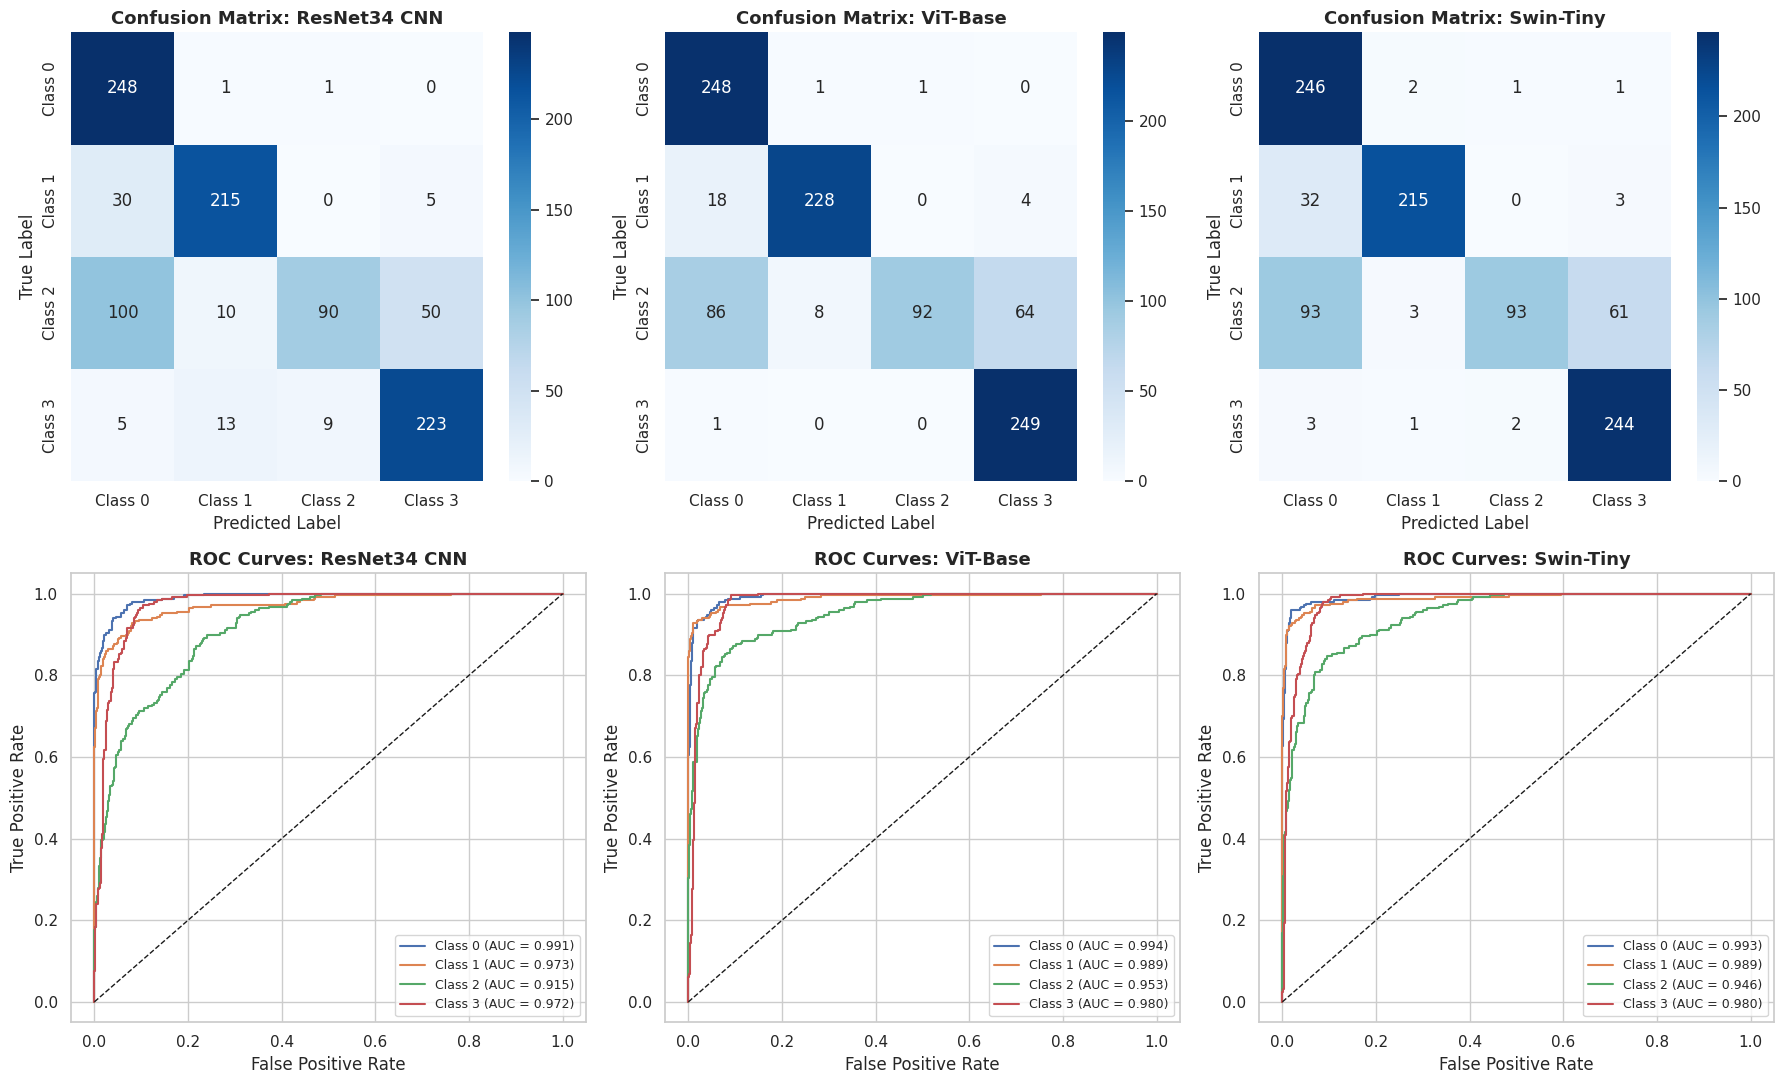


--- Visual Evaluation Plots Rendered and Saved as 'medical_evaluation_plots.png' ---


In [15]:
# Cell 5: Medical Evaluation Visualizations - Confusion Matrices and Multi-Class ROC Curves

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Set visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Helper to retrieve predictions & probabilities for plotting
@torch.no_grad()
def get_predictions(model, checkpoint_path, dataloader):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    all_probs, all_targets = [], []
    for images, targets in dataloader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        targets_np = targets.squeeze().long().numpy()
        all_probs.append(probs)
        all_targets.append(targets_np)
    return np.concatenate(all_probs, axis=0), np.concatenate(all_targets, axis=0)

models_dict = {
    "ResNet34 CNN": (model_cnn, "best_ResNet34_CNN.pth"),
    "ViT-Base": (model_vit, "best_ViT_Base.pth"),
    "Swin-Tiny": (model_swin, "best_Swin_Tiny.pth")
}

class_labels = [f"Class {i}" for i in range(actual_num_classes)]

for idx, (name, (model_obj, ckpt)) in enumerate(models_dict.items()):
    probs, targets = get_predictions(model_obj, ckpt, test_loader)
    preds = np.argmax(probs, axis=1)
    
    # 1. Confusion Matrix Plots (Top Row)
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                xticklabels=class_labels, yticklabels=class_labels)
    axes[0, idx].set_title(f"Confusion Matrix: {name}", fontsize=13, fontweight='bold')
    axes[0, idx].set_xlabel("Predicted Label")
    axes[0, idx].set_ylabel("True Label")
    
    # 2. One-vs-Rest ROC Curves (Bottom Row)
    targets_bin = label_binarize(targets, classes=list(range(actual_num_classes)))
    for c_idx in range(actual_num_classes):
        fpr, tpr, _ = roc_curve(targets_bin[:, c_idx], probs[:, c_idx])
        roc_auc = auc(fpr, tpr)
        axes[1, idx].plot(fpr, tpr, label=f"Class {c_idx} (AUC = {roc_auc:.3f})")
        
    axes[1, idx].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1, idx].set_title(f"ROC Curves: {name}", fontsize=13, fontweight='bold')
    axes[1, idx].set_xlabel("False Positive Rate")
    axes[1, idx].set_ylabel("True Positive Rate")
    axes[1, idx].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("medical_evaluation_plots.png", dpi=300)
plt.show()

print("\n--- Visual Evaluation Plots Rendered and Saved as 'medical_evaluation_plots.png' ---")